# Backtest Visualization Dashboard

**Updated:** 2026-04-06

This notebook is organized to show, in order:
1. Current default levered results
2. Unlevered `Expansion 1.00 / Transition 0.80 / Contraction 0.50` results
3. Direct performance metrics comparison for levered vs unlevered
4. Cost, financing, and exposure sensitivity


In [21]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from IPython.display import display, Markdown, HTML

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({
    "figure.figsize": (16, 7),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "axes.titlesize": 16,
    "legend.frameon": False,
})

BASE = Path('..')
REPORTS = BASE / 'reports'
SNAPSHOT_SWEEP = BASE / 'report_snapshots' / 'exposure_sensitivity_2026-04-06'
SNAPSHOT_UNLEVERED = BASE / 'report_snapshots' / 'unlevered_profile_2026-04-06'

BACKTEST_CSV = REPORTS / 'backtest_results.csv'
TURNOVER_TXT = REPORTS / 'turnover_report.txt'
RELIABILITY_TXT = REPORTS / 'reliability_report.txt'
QUARTER_LOG_TXT = REPORTS / 'quarter_log.txt'
SWEEP_SUMMARY_CSV = SNAPSHOT_SWEEP / 'exposure_sensitivity_summary.csv'
UNLEVERED_COMPARE_CSV = SNAPSHOT_UNLEVERED / 'compare_vs_levered.csv'
UNLEVERED_BT_CSV = SNAPSHOT_UNLEVERED / 'backtest_results.csv'

assert BACKTEST_CSV.exists(), f'Missing {BACKTEST_CSV}'
assert SWEEP_SUMMARY_CSV.exists(), f'Missing {SWEEP_SUMMARY_CSV}'
assert UNLEVERED_COMPARE_CSV.exists(), f'Missing {UNLEVERED_COMPARE_CSV}'
assert UNLEVERED_BT_CSV.exists(), f'Missing {UNLEVERED_BT_CSV}'

bt = pd.read_csv(BACKTEST_CSV)
bt['Date'] = pd.to_datetime(bt['Date'])
bt = bt.sort_values('Date').reset_index(drop=True)
ret_col = 'PortRetKS' if 'PortRetKS' in bt.columns else 'PortRet'
bt['StrategyRet'] = bt[ret_col].fillna(bt['PortRet'])
bt['StrategyEq'] = (1 + bt['StrategyRet']).cumprod()
bt['SPYEq'] = (1 + bt['SPYRet']).cumprod()

unlev = pd.read_csv(UNLEVERED_BT_CSV)
unlev['Date'] = pd.to_datetime(unlev['Date'])
unlev = unlev.sort_values('Date').reset_index(drop=True)
unlev_ret_col = 'PortRetKS' if 'PortRetKS' in unlev.columns else 'PortRet'
unlev['StrategyRet'] = unlev[unlev_ret_col].fillna(unlev['PortRet'])
unlev['StrategyEq'] = (1 + unlev['StrategyRet']).cumprod()
unlev['SPYEq'] = (1 + unlev['SPYRet']).cumprod()

compare_profiles = pd.read_csv(UNLEVERED_COMPARE_CSV)
sweep_summary = pd.read_csv(SWEEP_SUMMARY_CSV).sort_values('ExpansionExposure')

turnover_text = TURNOVER_TXT.read_text(encoding='utf-8') if TURNOVER_TXT.exists() else ''
reliability_text = RELIABILITY_TXT.read_text(encoding='utf-8') if RELIABILITY_TXT.exists() else ''
quarter_log_text = QUARTER_LOG_TXT.read_text(encoding='utf-8') if QUARTER_LOG_TXT.exists() else ''

colors = {
    'levered': '#0f766e',
    'unlevered': '#b45309',
    'spy': '#334155',
    'drawdown': '#dc2626',
    '1.10': '#94a3b8',
    '1.20': '#0f766e',
    '1.30': '#2563eb',
    '1.50': '#7c3aed',
}

pct_fmt = FuncFormatter(lambda y, _: f'{y:.0%}')

def pct(x, d=2):
    return '' if pd.isna(x) else f'{x:.{d}%}'

def num(x, d=2):
    return '' if pd.isna(x) else f'{x:.{d}f}'

def max_dd(eq):
    eq = pd.Series(eq).dropna()
    return np.nan if eq.empty else float((eq / eq.cummax() - 1).min())

def cagr(returns, periods=4):
    returns = pd.Series(returns).dropna()
    if returns.empty:
        return np.nan
    total = float((1 + returns).prod())
    years = len(returns) / periods
    return total ** (1 / years) - 1 if years else np.nan

def ann_vol(returns, periods=4):
    returns = pd.Series(returns).dropna()
    if len(returns) < 2:
        return np.nan
    return float(returns.std(ddof=1) * np.sqrt(periods))

def sharpe(returns, periods=4):
    r = cagr(returns, periods)
    v = ann_vol(returns, periods)
    return np.nan if pd.isna(v) or v == 0 else r / v

def sortino(returns, periods=4):
    returns = pd.Series(returns).dropna()
    if returns.empty:
        return np.nan
    downside = returns[returns < 0]
    if len(downside) < 2:
        return np.nan
    downside_vol = float(downside.std(ddof=1) * np.sqrt(periods))
    r = cagr(returns, periods)
    return np.nan if downside_vol == 0 or pd.isna(downside_vol) else r / downside_vol

def calmar(returns, equity, periods=4):
    r = cagr(returns, periods)
    dd = abs(max_dd(equity))
    return np.nan if dd == 0 or pd.isna(dd) else r / dd

def metrics_table(returns, equity, label, exec_bps, fin_bps):
    returns = pd.Series(returns).dropna()
    return {
        'Profile': label,
        'Total Return': float((1 + returns).prod() - 1) if not returns.empty else np.nan,
        'CAGR': cagr(returns),
        'Ann Vol': ann_vol(returns),
        'Sharpe': sharpe(returns),
        'Sortino': sortino(returns),
        'Max Drawdown': max_dd(equity),
        'Calmar': calmar(returns, equity),
        'Hit Rate': float((returns > 0).mean()) if not returns.empty else np.nan,
        'Best Quarter': float(returns.max()) if not returns.empty else np.nan,
        'Worst Quarter': float(returns.min()) if not returns.empty else np.nan,
        'Avg Execution Cost (bps/q)': exec_bps,
        'Avg Financing Cost (bps/q)': fin_bps,
    }

def card_html(title, value, subtitle):
    return f"<div style='padding:16px 18px;border:1px solid #d7dee7;border-radius:14px;background:#f8fafc;min-width:190px'><div style='font-size:12px;letter-spacing:.08em;text-transform:uppercase;color:#64748b;margin-bottom:8px'>{title}</div><div style='font-size:30px;font-weight:700;color:#0f172a'>{value}</div><div style='font-size:12px;color:#64748b;margin-top:8px'>{subtitle}</div></div>"


## Snapshot At A Glance

The first numbers below are the explicit levered vs unlevered outcomes discussed above.

In [22]:
levered_row = compare_profiles.loc[compare_profiles['Profile'].str.contains('Levered')].iloc[0]
unlevered_row = compare_profiles.loc[compare_profiles['Profile'].str.contains('Unlevered')].iloc[0]

cards = [
    ('Levered Total Return', pct(levered_row['TotalReturn']), 'Current default backtest'),
    ('Levered CAGR', pct(levered_row['AnnReturn']), 'Current default backtest'),
    ('Unlevered Total Return', pct(unlevered_row['TotalReturn']), 'Expansion 1.00 / Transition 0.80'),
    ('Unlevered CAGR', pct(unlevered_row['AnnReturn']), 'No leverage profile'),
    ('Levered Financing Cost', f"{levered_row['AvgFinancingCostBpsQ']:.2f} bps", 'Average per quarter'),
    ('CAGR Gap', pct(levered_row['AnnReturn'] - unlevered_row['AnnReturn']), 'Levered minus unlevered'),
]
html = "<div style='display:flex;flex-wrap:wrap;gap:14px;margin:10px 0 20px 0'>" + ''.join(card_html(*x) for x in cards) + '</div>'
display(HTML(html))

compare_display = compare_profiles.copy()
for col in ['TotalReturn', 'AnnReturn', 'AnnVol', 'MaxDrawdown']:
    compare_display[col] = compare_display[col].map(pct)
for col in ['Sharpe', 'AvgExecutionCostBpsQ', 'AvgFinancingCostBpsQ']:
    compare_display[col] = compare_display[col].map(num)
display(compare_display)


,Profile,TotalReturn,AnnReturn,AnnVol,Sharpe,MaxDrawdown,AvgExecutionCostBpsQ,AvgFinancingCostBpsQ
0,Levered 1.20/1.00/0.50,3632.84%,20.32%,13.82%,1.47,-11.60%,23.38,8.07
1,Unlevered 1.00/0.80/0.50,2033.33%,16.87%,12.11%,1.39,-11.60%,23.38,0.00


## Full Performance Metrics Table

This is the direct levered vs unlevered metrics table you asked for, including Sharpe, Sortino, Calmar, drawdown, hit rate, and cost metrics.

In [23]:
perf = pd.DataFrame([
    metrics_table(
        bt['StrategyRet'],
        bt['StrategyEq'],
        'Levered 1.20 / 1.00 / 0.50',
        float(bt['TxnCostBps'].mean()),
        float(bt['FinancingCostRet'].mean() * 1e4),
    ),
    metrics_table(
        unlev['StrategyRet'],
        unlev['StrategyEq'],
        'Unlevered 1.00 / 0.80 / 0.50',
        float(unlev['TxnCostBps'].mean()),
        float(unlev['FinancingCostRet'].mean() * 1e4),
    ),
    metrics_table(
        bt['SPYRet'],
        bt['SPYEq'],
        'SPY',
        np.nan,
        np.nan,
    ),
])

perf_display = perf.copy()
for col in ['Total Return', 'CAGR', 'Ann Vol', 'Max Drawdown', 'Hit Rate', 'Best Quarter', 'Worst Quarter']:
    perf_display[col] = perf_display[col].map(pct)
for col in ['Sharpe', 'Sortino', 'Calmar', 'Avg Execution Cost (bps/q)', 'Avg Financing Cost (bps/q)']:
    perf_display[col] = perf_display[col].map(num)
display(perf_display)


,Profile,Total Return,CAGR,Ann Vol,Sharpe,Sortino,Max Drawdown,Calmar,Hit Rate,Best Quarter,Worst Quarter,Avg Execution Cost (bps/q),Avg Financing Cost (bps/q)
0,Levered 1.20 / 1.00 / 0.50,3841.49%,19.63%,13.63%,1.44,3.74,-10.72%,1.83,73.17%,27.53%,-9.73%,23.38,8.07
1,Unlevered 1.00 / 0.80 / 0.50,2152.58%,16.41%,11.90%,1.38,3.09,-10.72%,1.53,73.17%,23.11%,-9.73%,23.38,0.00
2,SPY,736.80%,10.92%,15.84%,0.69,0.87,-45.96%,0.24,75.61%,20.16%,-21.57%,,


## Levered vs Unlevered Equity Curves

This chart is the direct answer to the leverage trade-off question.

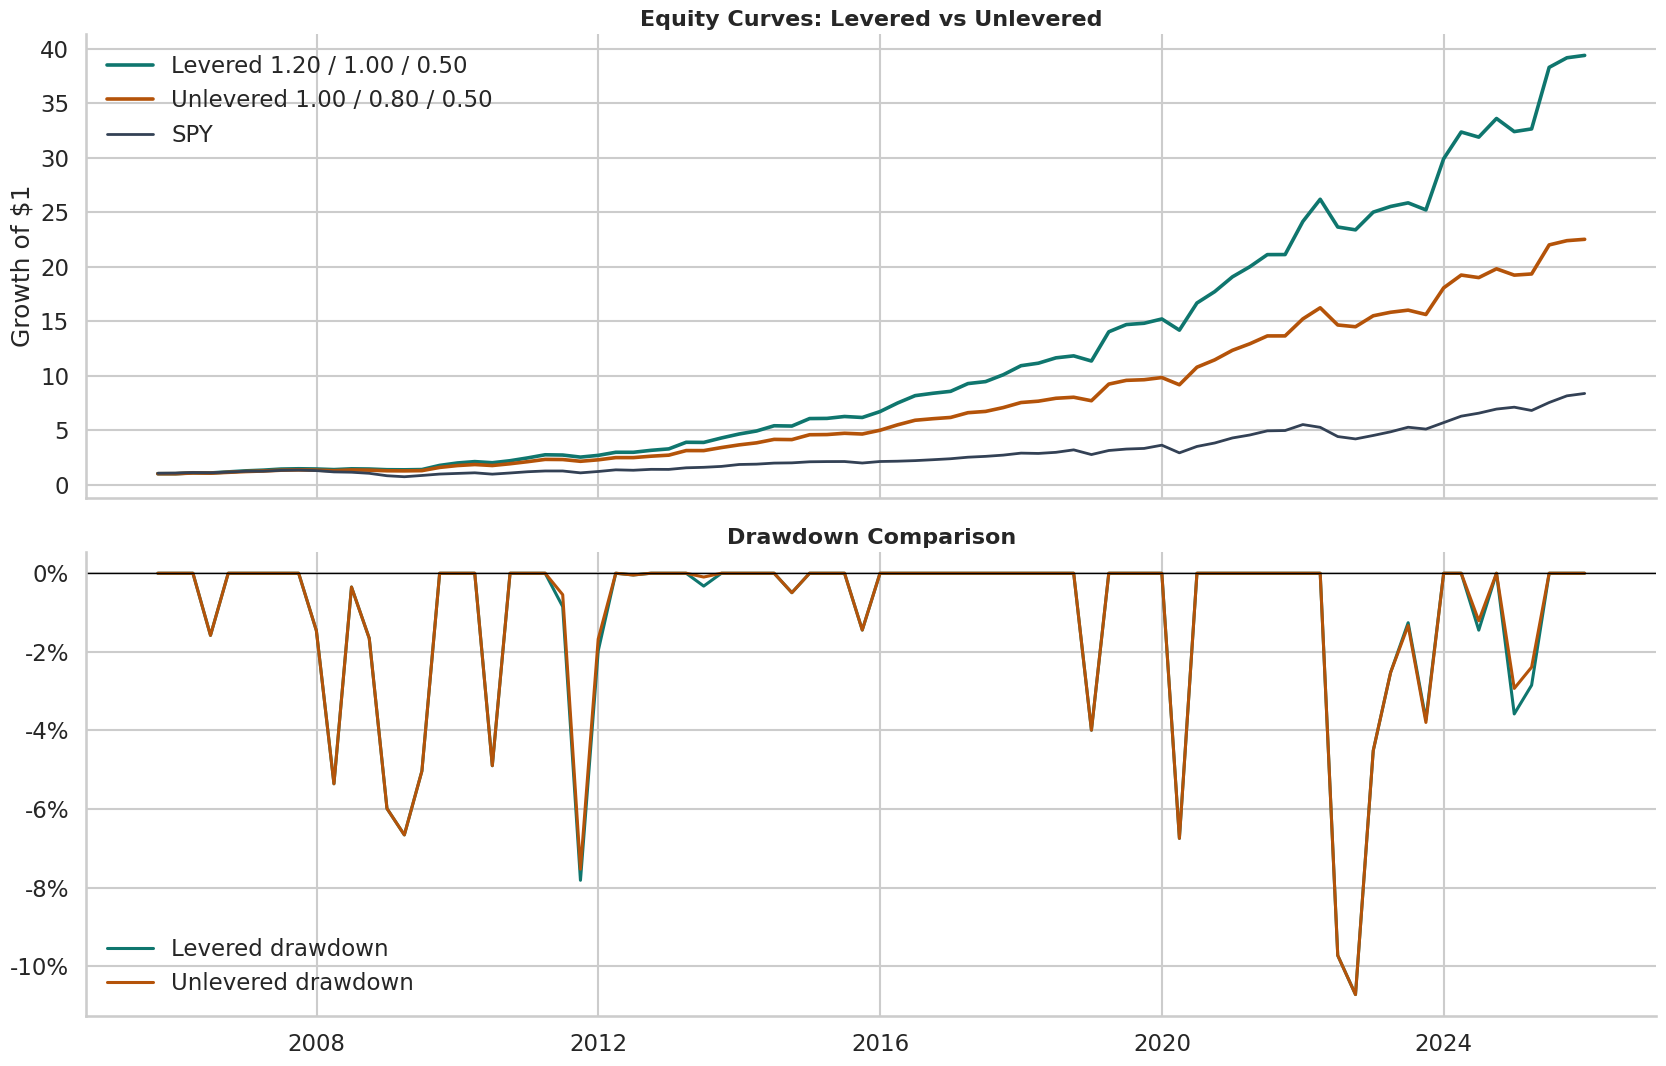

In [24]:
fig, axes = plt.subplots(2, 1, figsize=(17, 11), sharex=True)

axes[0].plot(bt['Date'], bt['StrategyEq'], linewidth=2.6, color=colors['levered'], label='Levered 1.20 / 1.00 / 0.50')
axes[0].plot(unlev['Date'], unlev['StrategyEq'], linewidth=2.6, color=colors['unlevered'], label='Unlevered 1.00 / 0.80 / 0.50')
axes[0].plot(bt['Date'], bt['SPYEq'], linewidth=2.0, color=colors['spy'], label='SPY')
axes[0].set_title('Equity Curves: Levered vs Unlevered')
axes[0].set_ylabel('Growth of $1')
axes[0].legend(loc='upper left')

levered_dd = bt['StrategyEq'] / bt['StrategyEq'].cummax() - 1
unlevered_dd = unlev['StrategyEq'] / unlev['StrategyEq'].cummax() - 1
axes[1].plot(bt['Date'], levered_dd, linewidth=2.2, color=colors['levered'], label='Levered drawdown')
axes[1].plot(unlev['Date'], unlevered_dd, linewidth=2.2, color=colors['unlevered'], label='Unlevered drawdown')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].yaxis.set_major_formatter(pct_fmt)
axes[1].set_title('Drawdown Comparison')
axes[1].legend(loc='lower left')

plt.tight_layout()
plt.show()


## Current Default Backtest Performance

This section shows the current default financed backtest against SPY.

In [25]:
current_perf = pd.DataFrame([
    metrics_table(bt['StrategyRet'], bt['StrategyEq'], 'Strategy', float(bt['TxnCostBps'].mean()), float(bt['FinancingCostRet'].mean() * 1e4)),
    metrics_table(bt['SPYRet'], bt['SPYEq'], 'SPY', np.nan, np.nan),
])
current_display = current_perf.copy()
for col in ['Total Return', 'CAGR', 'Ann Vol', 'Max Drawdown', 'Hit Rate', 'Best Quarter', 'Worst Quarter']:
    current_display[col] = current_display[col].map(pct)
for col in ['Sharpe', 'Sortino', 'Calmar', 'Avg Execution Cost (bps/q)', 'Avg Financing Cost (bps/q)']:
    current_display[col] = current_display[col].map(num)
display(current_display)


,Profile,Total Return,CAGR,Ann Vol,Sharpe,Sortino,Max Drawdown,Calmar,Hit Rate,Best Quarter,Worst Quarter,Avg Execution Cost (bps/q),Avg Financing Cost (bps/q)
0,Strategy,3841.49%,19.63%,13.63%,1.44,3.74,-10.72%,1.83,73.17%,27.53%,-9.73%,23.38,8.07
1,SPY,736.80%,10.92%,15.84%,0.69,0.87,-45.96%,0.24,75.61%,20.16%,-21.57%,,


## Costs And Financing

These are the implementation frictions for the current default run.

,Metric,Value
0,Average Turnover,69.57%
1,Average Execution Cost (bps/q),23.38
2,Average Financing Cost (bps/q),8.07
3,Average Borrowed Notional (USD),"$417,136"
4,Average Financing Rate,4.67%
5,Average Holdings,28.90


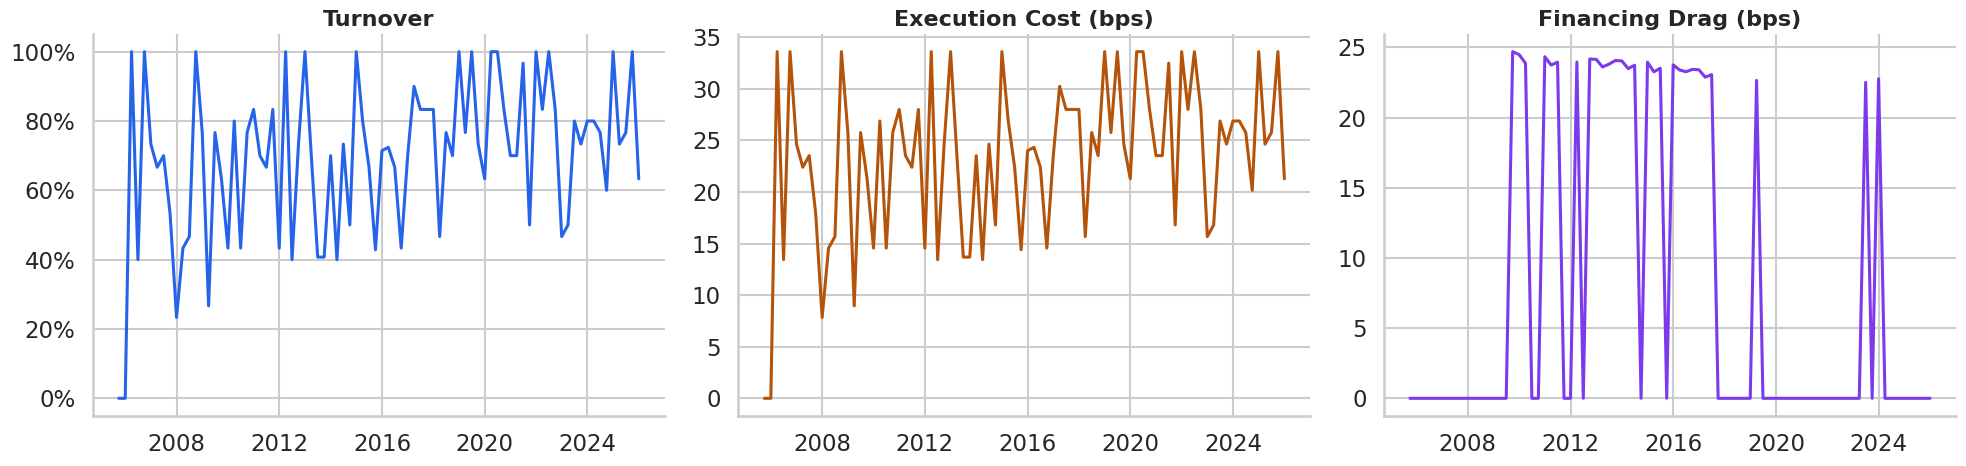

In [26]:
cost_table = pd.DataFrame({
    'Metric': [
        'Average Turnover',
        'Average Execution Cost (bps/q)',
        'Average Financing Cost (bps/q)',
        'Average Borrowed Notional (USD)',
        'Average Financing Rate',
        'Average Holdings',
    ],
    'Value': [
        pct(bt['Turnover'].mean()),
        num(bt['TxnCostBps'].mean()),
        num(bt['FinancingCostRet'].mean() * 1e4),
        f"${bt['BorrowedNotionalUSD'].mean():,.0f}",
        pct(bt.loc[bt['FinancingRateAnnual'] > 0, 'FinancingRateAnnual'].mean()),
        num(bt['NHoldings'].mean()),
    ]
})
display(cost_table)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
axes[0].plot(bt['Date'], bt['Turnover'], color='#2563eb', linewidth=2.2)
axes[0].set_title('Turnover')
axes[0].yaxis.set_major_formatter(pct_fmt)

axes[1].plot(bt['Date'], bt['TxnCostBps'], color='#b45309', linewidth=2.2)
axes[1].set_title('Execution Cost (bps)')

axes[2].plot(bt['Date'], bt['FinancingCostRet'] * 1e4, color='#7c3aed', linewidth=2.2)
axes[2].set_title('Financing Drag (bps)')

plt.tight_layout()
plt.show()


## Expansion Exposure Sensitivity

This uses the financed sweep snapshots for `1.10 / 1.20 / 1.30 / 1.50`, plus the unlevered profile as a dashed reference.

In [27]:
sweep_display = sweep_summary.copy()
for col in ['TotalReturn', 'AnnReturn', 'AnnVol', 'MaxDrawdown', 'HitRate', 'AvgQuarterRet', 'AvgExpansionQuarter', 'AvgTransitionQuarter', 'AvgContractionQuarter', 'AvgFinancingRateAnnual']:
    sweep_display[col] = sweep_display[col].map(pct)
for col in ['ExpansionExposure', 'FinalEquity', 'Sharpe', 'AvgFinancingCostBpsQ']:
    sweep_display[col] = sweep_display[col].map(num)
display(sweep_display)


,ExpansionExposure,TotalReturn,FinalEquity,AnnReturn,AnnVol,Sharpe,MaxDrawdown,HitRate,AvgQuarterRet,AvgExpansionQuarter,AvgTransitionQuarter,AvgContractionQuarter,AvgFinancingCostBpsQ,AvgFinancingRateAnnual,SPYTotalReturn
0,1.10,3251.51%,33.52,18.69%,12.97%,1.44,-10.72%,73.17%,4.57%,8.17%,5.52%,0.77%,4.13,4.77%,7.368001
1,1.20,3841.49%,39.41,19.63%,13.63%,1.44,-10.72%,73.17%,4.80%,8.83%,5.52%,0.77%,8.07,4.67%,7.368001
2,1.30,4530.91%,46.31,20.57%,14.32%,1.44,-10.72%,73.17%,5.02%,9.49%,5.52%,0.77%,11.94,4.60%,7.368001
3,1.50,6269.18%,63.69,22.46%,15.77%,1.42,-10.72%,73.17%,5.48%,10.82%,5.52%,0.77%,19.55,4.52%,7.368001


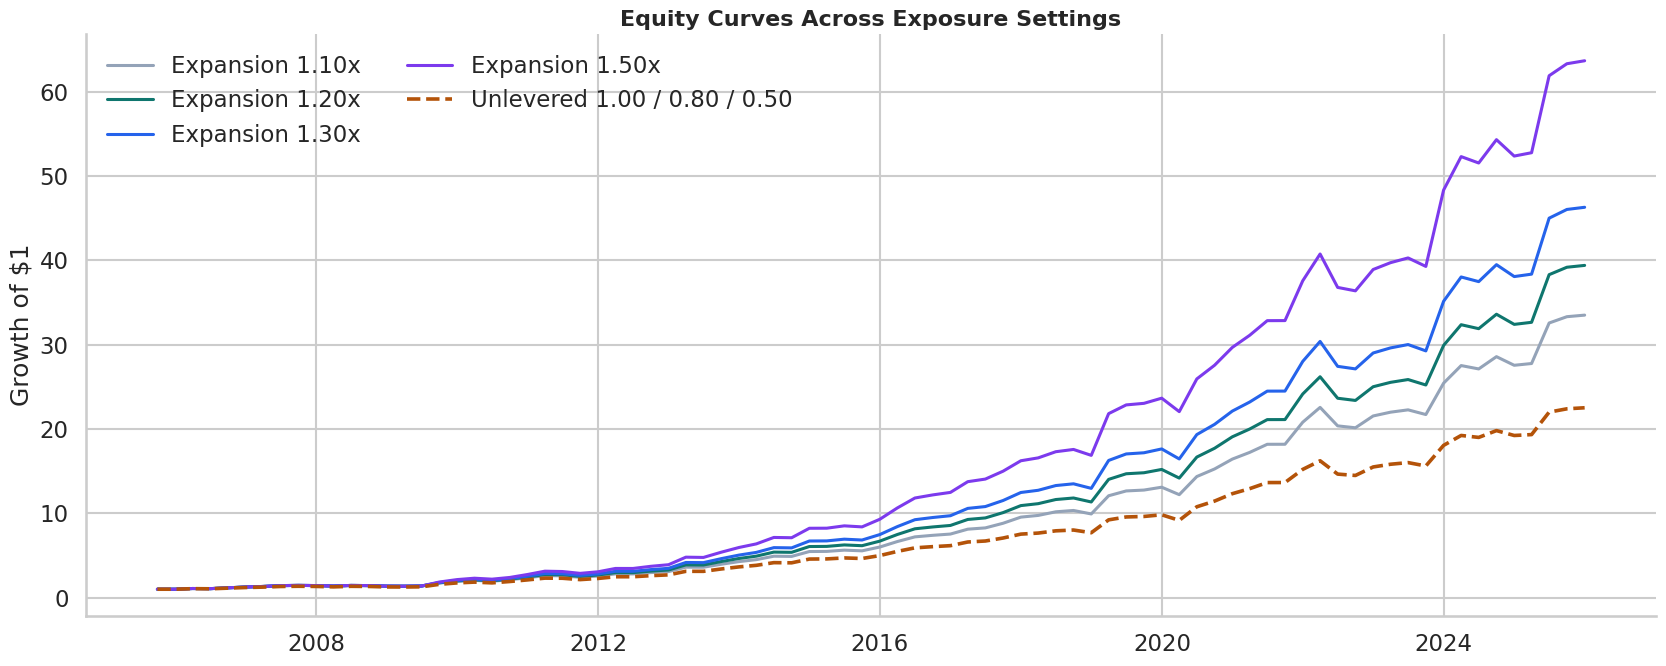

In [28]:
files = {
    1.10: SNAPSHOT_SWEEP / 'backtest_results_expansion_1p10.csv',
    1.20: SNAPSHOT_SWEEP / 'backtest_results_expansion_1p20.csv',
    1.30: SNAPSHOT_SWEEP / 'backtest_results_expansion_1p30.csv',
    1.50: SNAPSHOT_SWEEP / 'backtest_results_expansion_1p50.csv',
}

fig, ax = plt.subplots(figsize=(17, 7))
for exposure, key in [(1.10, '1.10'), (1.20, '1.20'), (1.30, '1.30'), (1.50, '1.50')]:
    df = pd.read_csv(files[exposure])
    df['Date'] = pd.to_datetime(df['Date'])
    rcol = 'PortRetKS' if 'PortRetKS' in df.columns else 'PortRet'
    eq = (1 + df[rcol].fillna(df['PortRet'])).cumprod()
    ax.plot(df['Date'], eq, linewidth=2.2, color=colors[key], label=f'Expansion {exposure:.2f}x')

ax.plot(unlev['Date'], unlev['StrategyEq'], linewidth=2.6, linestyle='--', color=colors['unlevered'], label='Unlevered 1.00 / 0.80 / 0.50')
ax.set_title('Equity Curves Across Exposure Settings')
ax.set_ylabel('Growth of $1')
ax.legend(loc='upper left', ncol=2)
plt.tight_layout()
plt.show()


## Regime View

This shows how often each regime occurred and the average return and exposure in each state for the current default run.

/tmp/ipykernel_32340/4001644475.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=regime_perf, x='Regime', y='Quarters', ax=axes[0], palette='crest')
/tmp/ipykernel_32340/4001644475.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=regime_perf, x='Regime', y='AvgReturn', ax=axes[1], palette='flare')
/tmp/ipykernel_32340/4001644475.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=regime_perf, x='Regime', y='AvgExposure', ax=axes[2], palette='mako')


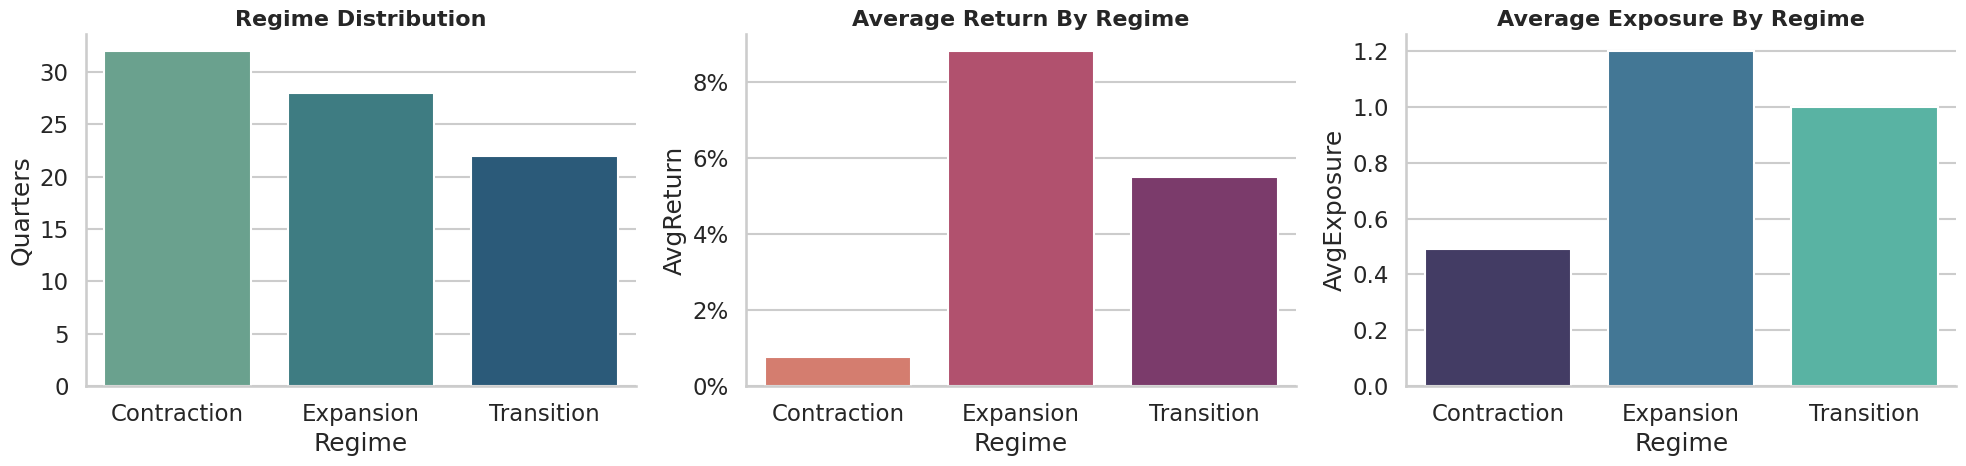

,Regime,Quarters,AvgReturn,AvgExposure,AvgTurnover
0,Contraction,32,0.77%,0.49,61.03%
1,Expansion,28,8.83%,1.20,71.26%
2,Transition,22,5.52%,1.00,79.85%


In [29]:
regime_perf = bt.groupby('Regime', dropna=False).agg(
    Quarters=('Date', 'count'),
    AvgReturn=('StrategyRet', 'mean'),
    AvgExposure=('RegimeExp', 'mean'),
    AvgTurnover=('Turnover', 'mean'),
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
sns.barplot(data=regime_perf, x='Regime', y='Quarters', ax=axes[0], palette='crest')
axes[0].set_title('Regime Distribution')

sns.barplot(data=regime_perf, x='Regime', y='AvgReturn', ax=axes[1], palette='flare')
axes[1].set_title('Average Return By Regime')
axes[1].yaxis.set_major_formatter(pct_fmt)

sns.barplot(data=regime_perf, x='Regime', y='AvgExposure', ax=axes[2], palette='mako')
axes[2].set_title('Average Exposure By Regime')

plt.tight_layout()
plt.show()

regime_display = regime_perf.copy()
for col in ['AvgReturn', 'AvgTurnover']:
    regime_display[col] = regime_display[col].map(pct)
regime_display['AvgExposure'] = regime_display['AvgExposure'].map(num)
display(regime_display)


## Quarterly Path And Extremes

This section shows the quarter-by-quarter return path and the best and worst quarters.

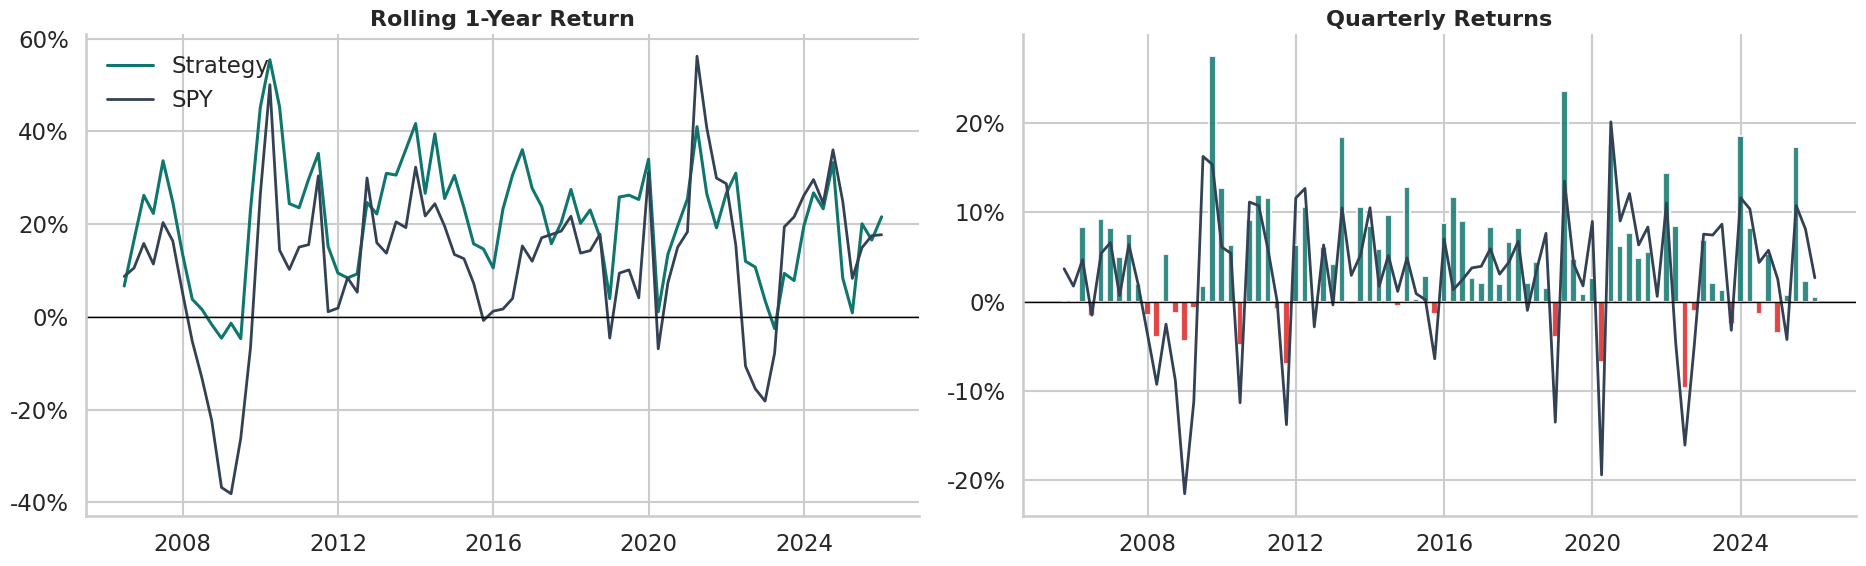

In [30]:
rolling = bt[['Date', 'StrategyRet', 'SPYRet']].copy()
rolling['StrategyRolling1Y'] = rolling['StrategyRet'].rolling(4).apply(lambda x: np.prod(1 + x) - 1, raw=True)
rolling['SPYRolling1Y'] = rolling['SPYRet'].rolling(4).apply(lambda x: np.prod(1 + x) - 1, raw=True)

fig, axes = plt.subplots(1, 2, figsize=(19, 6))
axes[0].plot(rolling['Date'], rolling['StrategyRolling1Y'], color=colors['levered'], linewidth=2.2, label='Strategy')
axes[0].plot(rolling['Date'], rolling['SPYRolling1Y'], color=colors['spy'], linewidth=2.0, label='SPY')
axes[0].axhline(0, color='black', linewidth=1)
axes[0].yaxis.set_major_formatter(pct_fmt)
axes[0].set_title('Rolling 1-Year Return')
axes[0].legend(loc='upper left')

bar_colors = np.where(bt['StrategyRet'] >= 0, colors['levered'], '#dc2626')
axes[1].bar(bt['Date'], bt['StrategyRet'], width=65, color=bar_colors, alpha=0.85)
axes[1].plot(bt['Date'], bt['SPYRet'], color=colors['spy'], linewidth=2.0)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].yaxis.set_major_formatter(pct_fmt)
axes[1].set_title('Quarterly Returns')

plt.tight_layout()
plt.show()


In [31]:
ext = bt[['Date', 'StrategyRet', 'SPYRet', 'Regime', 'PredSectorNames', 'RealTopSectors']].copy()
ext = ext.sort_values('StrategyRet', ascending=False)

def fmt(df):
    out = df.copy()
    out['Date'] = pd.to_datetime(out['Date']).dt.date.astype(str)
    for col in ['StrategyRet', 'SPYRet']:
        out[col] = out[col].map(pct)
    return out

display(Markdown('### Best 10 Quarters'))
display(fmt(ext.head(10)))

display(Markdown('### Worst 10 Quarters'))
display(fmt(ext.tail(10).sort_values('StrategyRet')))


### Best 10 Quarters

,Date,StrategyRet,SPYRet,Regime,PredSectorNames,RealTopSectors
16,2009-09-30,27.53%,15.38%,Expansion,"Materials,Financials,Real Estate","Financials,Materials,Real Estate"
54,2019-03-31,23.63%,13.53%,Expansion,"Industrials,Consumer Discretionary,Information...","Information Technology,Energy,Consumer Discret..."
73,2023-12-31,18.61%,11.64%,Expansion,"Consumer Discretionary,Industrials,Health Care","Real Estate,Information Technology,Financials"
30,2013-03-31,18.51%,10.50%,Expansion,"Communication Services,Energy,Utilities","Communication Services,Consumer Staples,Financ..."
59,2020-06-30,17.58%,20.16%,Contraction,"Consumer Discretionary,Energy,Industrials","Energy,Consumer Discretionary,Information Tech..."
79,2025-06-30,17.30%,10.78%,Transition,"Communication Services,Consumer Discretionary,...","Information Technology,Communication Services,..."
65,2021-12-31,14.37%,11.07%,Transition,"Information Technology,Consumer Staples,Health...","Information Technology,Real Estate,Materials"
37,2014-12-31,12.80%,4.90%,Expansion,"Information Technology,Industrials,Utilities","Real Estate,Utilities,Consumer Discretionary"
17,2009-12-31,12.71%,6.11%,Expansion,"Materials,Consumer Discretionary,Real Estate","Information Technology,Health Care,Real Estate"
21,2010-12-31,11.90%,10.76%,Expansion,"Materials,Consumer Discretionary,Financials","Energy,Materials,Financials"


### Worst 10 Quarters

,Date,StrategyRet,SPYRet,Regime,PredSectorNames,RealTopSectors
67,2022-06-30,-9.73%,-16.11%,Contraction,"Consumer Discretionary,Industrials,Information...","Consumer Staples,Utilities,Energy"
24,2011-09-30,-7.02%,-13.82%,Contraction,"Utilities,Information Technology,Industrials","Utilities,Consumer Staples,Consumer Discretionary"
58,2020-03-31,-6.75%,-19.45%,Contraction,"Information Technology,Utilities,Consumer Staples","Consumer Staples,Health Care,Utilities"
19,2010-06-30,-4.90%,-11.36%,Contraction,"Energy,Utilities,Consumer Discretionary","Utilities,Consumer Staples,Real Estate"
13,2008-12-31,-4.40%,-21.57%,Contraction,"Utilities,Information Technology,Consumer Disc...","Utilities,Consumer Staples,Health Care"
53,2018-12-31,-3.99%,-13.53%,Contraction,"Utilities,Consumer Staples,Information Technology","Utilities,Real Estate,Consumer Staples"
10,2008-03-31,-3.95%,-9.29%,Contraction,"Energy,Information Technology,Materials","Real Estate,Consumer Discretionary,Energy"
77,2024-12-31,-3.58%,2.49%,Transition,"Communication Services,Real Estate,Materials","Communication Services,Financials,Consumer Dis..."
72,2023-09-30,-2.50%,-3.22%,Contraction,"Consumer Discretionary,Financials,Materials","Energy,Financials,Information Technology"
3,2006-06-30,-1.58%,-1.53%,Contraction,"Energy,Materials,Financials","Energy,Consumer Staples,Communication Services"


## Text Reports

Kept last so the notebook stays visual first. This cell is now robust and should not fail on the excerpt section.

In [32]:
if reliability_text.strip():
    display(Markdown('### Reliability Report'))
    print(reliability_text)
else:
    display(Markdown('### Reliability Report'))
    print('No reliability report found.')

if turnover_text.strip():
    display(Markdown('### Turnover / Financing Report'))
    print(turnover_text)
else:
    display(Markdown('### Turnover / Financing Report'))
    print('No turnover report found.')

if quarter_log_text.strip():
    display(Markdown('### Quarter Log Preview'))
    print('\n'.join(quarter_log_text.splitlines()[:40]))
else:
    display(Markdown('### Quarter Log Preview'))
    print('No quarter log found.')


### Reliability Report

Reliability Score Report
Score: 61.0/100
Target: 55.0
Status: PASS
Drivers:
- Data checks WARN count: 3
- Coverage warning present.
- History has tickers not in prices.
- Extreme monthly return outliers present.
Action: acceptable to present with disclosed assumptions.


### Turnover / Financing Report

Turnover / Execution Cost Summary
Average holdings per quarter: 28.90
Average turnover (one-way): 69.57%
Median turnover (one-way): 73.33%
Average applied execution cost: 23.38 bps per quarter
Average financing drag: 8.07 bps per quarter
Average annualized financing rate on borrowed balance: 4.67%
Average borrowed notional (USD, using configured account NAV): $417,136
IBKR-style one-way cost assumption (bps): commission=0.40 + exchange=0.20 + spread=8.00 + slippage=10.00 + impact=15.00 = 33.60
IBKR Pro USD financing assumption: blended benchmark-plus-spread tiers for 0-100k, 100k-1m, 1m-50m, 50m-250m, and 250m+ borrowed balances.
Benchmark proxy used in backtest: 3.64% annual.
Note: fixed per-order minimum ticket costs are approximated in commission bps.


### Quarter Log Preview


=== 2005-09-30 ===
Predicted sectors (ETFs): []
Predicted sector names   : []
Real top sectors         : ['Energy', 'Information Technology', 'Utilities']
Portfolio return         : 0.00% | SPY 3.68%
Gross return / execution / financing: 0.00% / 0.00 bps / 0.00%
Borrowed notional / annual rate: $0 / 0.00%
Holdings / turnover      : 0 / 0.00%
Top20 stocks in pred sectors: 0/20
Stock picks:

=== 2005-12-31 ===
Predicted sectors (ETFs): []
Predicted sector names   : []
Real top sectors         : ['Financials', 'Materials', 'Industrials']
Portfolio return         : 0.00% | SPY 1.73%
Gross return / execution / financing: 0.00% / 0.00 bps / 0.00%
Borrowed notional / annual rate: $0 / 0.00%
Holdings / turnover      : 0 / 0.00%
Top20 stocks in pred sectors: 0/20
Stock picks:

=== 2006-03-31 ===
Predicted sectors (ETFs): ['Energy', 'Materials', 'Consumer Discretionary']
Predicted sector names   : ['Energy', 'Materials', 'Consumer Discretionary']
Real top sectors         : ['Real Estate', 'Mate